## Imports and packages

In [2]:

# !pip install ISLP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

from ISLP import load_data

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


---
## Q 3

**Setup.** This is a QDA problem with $p = 1$ feature. If an observation belongs to class $k$, then

$$X \mid Y = k \;\sim\; N(\mu_k, \sigma_k^2)$$



$$f_k(x) = \frac{1}{\sqrt{2\pi}\,\sigma_k} \exp\!\left(-\frac{(x-\mu_k)^2}{2\sigma_k^2}\right)$$

**Goal.** Show that the Bayes classifier assigns $x$ to the class that maximizes a function of $x$ that is **quadratic** in $x$ (not linear), when the $\sigma_k$ are allowed to differ across classes.

### Derivation

By Bayes' theorem, the posterior probability that an observation with $X = x$ belongs to class $k$ is

$$p_k(x) = \frac{\pi_k f_k(x)}{\sum_{l=1}^{K} \pi_l f_l(x)}$$

The Bayes classifier assigns $x$ to the class $k$ that maximizes $p_k(x)$. Since the denominator does not depend on $k$, this is equivalent to maximizing $\pi_k f_k(x)$, or equivalently (since $\log$ is monotonic) maximizing its log:

$$\delta_k(x) = \log(\pi_k f_k(x)) = \log \pi_k + \log f_k(x)$$

Substituting the normal density:

$$\delta_k(x) = \log \pi_k - \log(\sqrt{2\pi}) - \log \sigma_k - \frac{(x - \mu_k)^2}{2\sigma_k^2}$$

Expanding the squared term $(x-\mu_k)^2 = x^2 - 2\mu_k x + \mu_k^2$:

$$\delta_k(x) = \log \pi_k - \log \sigma_k - \frac{x^2}{2\sigma_k^2} + \frac{\mu_k x}{\sigma_k^2} - \frac{\mu_k^2}{2\sigma_k^2} - \log(\sqrt{2\pi})$$

Dropping the constant term $-\log(\sqrt{2\pi})$ (it is the same for every class, so it doesn't affect which class is chosen), the discriminant function is

$$\boxed{\;\delta_k(x) = -\frac{1}{2\sigma_k^2}x^2 + \frac{\mu_k}{\sigma_k^2}x - \frac{\mu_k^2}{2\sigma_k^2} - \log \sigma_k + \log \pi_k\;}$$

### Why this is quadratic, not linear

$\delta_k(x)$ is a **quadratic function of $x$**: it contains a term in $x^2$ with coefficient $-\dfrac{1}{2\sigma_k^2}$.

In LDA, we *assume* $\sigma_1^2 = \sigma_2^2 = \cdots = \sigma_K^2 = \sigma^2$. In that special case, the $x^2$ coefficient $-\dfrac{1}{2\sigma^2}$ is **identical for every class**, so when we compare $\delta_k(x)$ and $\delta_l(x)$ (e.g., to find the decision boundary where $\delta_k(x) = \delta_l(x)$), the $x^2$ terms cancel out, leaving a linear equation in $x$. That is why LDA produces linear decision boundaries.

Here, however, we are **not** assuming equal variances. The coefficient of $x^2$ in $\delta_k(x)$ is $-\dfrac{1}{2\sigma_k^2}$, which **depends on $k$** whenever $\sigma_k \ne \sigma_l$. So when we set $\delta_k(x) = \delta_l(x)$ to find where the classifier switches from predicting class $k$ to predicting class $l$:

$$-\frac{1}{2\sigma_k^2}x^2 + \frac{\mu_k}{\sigma_k^2}x - \frac{\mu_k^2}{2\sigma_k^2} - \log\sigma_k + \log\pi_k \;=\; -\frac{1}{2\sigma_l^2}x^2 + \frac{\mu_l}{\sigma_l^2}x - \frac{\mu_l^2}{2\sigma_l^2} - \log\sigma_l + \log\pi_l$$

the $x^2$ terms do **not** cancel (since $\dfrac{1}{\sigma_k^2} \ne \dfrac{1}{\sigma_l^2}$), and rearranging leaves a genuine quadratic equation in $x$:

$$\left(\frac{1}{\sigma_l^2} - \frac{1}{\sigma_k^2}\right)\frac{x^2}{2} + \left(\frac{\mu_k}{\sigma_k^2} - \frac{\mu_l}{\sigma_l^2}\right)x + \left(\text{constant}\right) = 0$$

This has (up to) **two** solutions for $x$, meaning the boundary between the two classes can consist of up to two points on the real line (rather than the single boundary point/hyperplane that LDA would give). This confirms that the Bayes classifier is **quadratic** — hence the name Quadratic Discriminant Analysis (QDA). $\blacksquare$

The cell below just gives a quick numerical/graphical illustration of this with two synthetic classes with different variances.


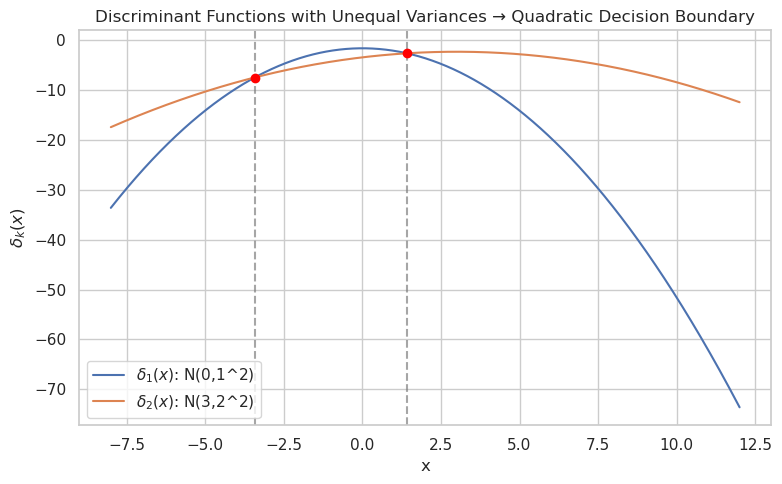

Number of decision-boundary crossing points found: 2
Two crossing points (rather than one) are possible because unequal variances produce a quadratic equation in x.


In [10]:


# Two 1-D Gaussian classes with different sigma
mu1, sigma1, pi1 = 0, 1, 0.5
mu2, sigma2, pi2 = 3, 2, 0.5

x = np.linspace(-8, 12, 2000)

def delta(x, mu, sigma, pi):
    return (
        -0.5 * np.log(2 * np.pi)
        - np.log(sigma)
        - (x - mu)**2 / (2 * sigma**2)
        + np.log(pi)
    )

d1 = delta(x, mu1, sigma1, pi1)
d2 = delta(x, mu2, sigma2, pi2)

plt.figure(figsize=(8, 5))

# Use raw f-strings: rf'...'
plt.plot(
    x, d1,
    label=rf'$\delta_1(x)$: N({mu1},{sigma1}^2)'
)

plt.plot(
    x, d2,
    label=rf'$\delta_2(x)$: N({mu2},{sigma2}^2)'
)

# Find crossing points numerically
diff = d1 - d2
sign_changes = np.where(np.diff(np.sign(diff)))[0]

for idx in sign_changes:
    plt.axvline(
        x[idx],
        color='gray',
        linestyle='--',
        alpha=0.7
    )

    plt.scatter(
        x[idx],
        d1[idx],
        color='red',
        zorder=5
    )

plt.xlabel('x')
plt.ylabel(r'$\delta_k(x)$')

plt.title(
    'Discriminant Functions with Unequal Variances '
    '→ Quadratic Decision Boundary'
)

plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Number of decision-boundary crossing points found: "
    f"{len(sign_changes)}"
)

print(
    "Two crossing points (rather than one) are possible "
    "because unequal variances produce a quadratic equation in x."
)

---
## Q 8

**Setup.**
- Logistic regression: training error = 20%, test error = 30%.
- 1-nearest neighbors (K = 1): **average** error rate (averaged over training *and* test) = 18%.

**Which method should we prefer for classifying new observations?**

### Key insight about 1-NN

For **K = 1** nearest neighbors evaluated on the *training set*, each training point's single nearest neighbor is **itself** (distance 0). Therefore the training error rate for 1-NN is always **exactly 0%**.

Let $\text{Test}_{KNN}$ be the (unknown) test error rate for 1-NN. We're told the *average* of the training and test error is 18%:

$$\frac{0\% + \text{Test}_{KNN}}{2} = 18\% \quad\Longrightarrow\quad \text{Test}_{KNN} = 36\%$$

### Conclusion

| Method | Train error | Test error |
|---|---|---|
| Logistic regression | 20% | **30%** |
| 1-NN (K=1) | 0% | **36%** |

We should choose the method based on **test error**, since that estimates how well the method generalizes to new data. Logistic regression's test error (30%) is lower than 1-NN's implied test error (36%), so **logistic regression is preferred**.


In [5]:
# Quick numeric check of the algebra above
train_logreg, test_logreg = 0.20, 0.30
avg_knn = 0.18
train_knn = 0.0  # 1-NN always has 0% training error

test_knn = 2*avg_knn - train_knn
print(f"Logistic regression -> train: {train_logreg:.0%}, test: {test_logreg:.0%}")
print(f"1-NN (K=1)           -> train: {train_knn:.0%}, implied test: {test_knn:.0%}")
print()
print("Preferred method (lower test error):",
      "Logistic Regression" if test_logreg < test_knn else "1-NN")


Logistic regression -> train: 20%, test: 30%
1-NN (K=1)           -> train: 0%, implied test: 36%

Preferred method (lower test error): Logistic Regression


---
## Q13 — The `Weekly` stock market data set

### (a) Load the data and produce numerical / graphical summaries

In [7]:
Weekly = load_data('Weekly')
print(Weekly.shape)
Weekly.head()


(1089, 9)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [9]:
Weekly.describe()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [11]:
Weekly['Direction'].value_counts()


Direction
Up      605
Down    484
Name: count, dtype: int64

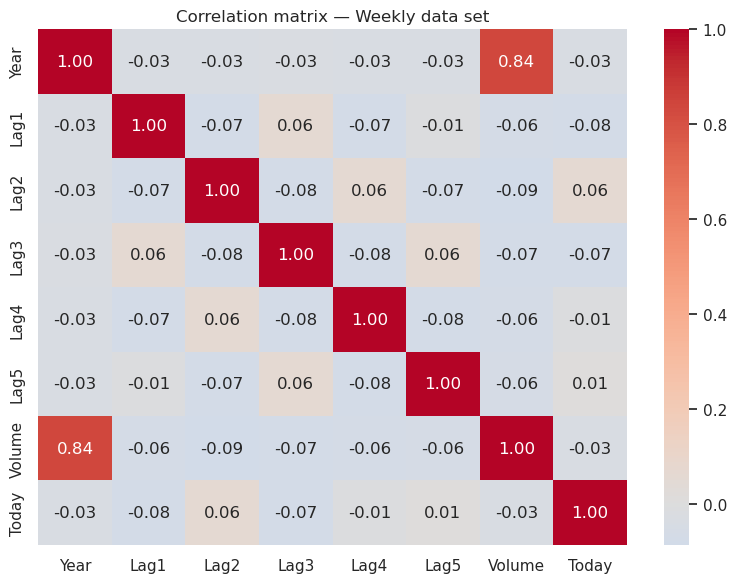

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


In [13]:
# Correlation matrix (numeric columns only)
numeric_cols = Weekly.select_dtypes(include=[np.number]).columns
corr = Weekly[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — Weekly data set')
plt.tight_layout()
plt.show()

corr


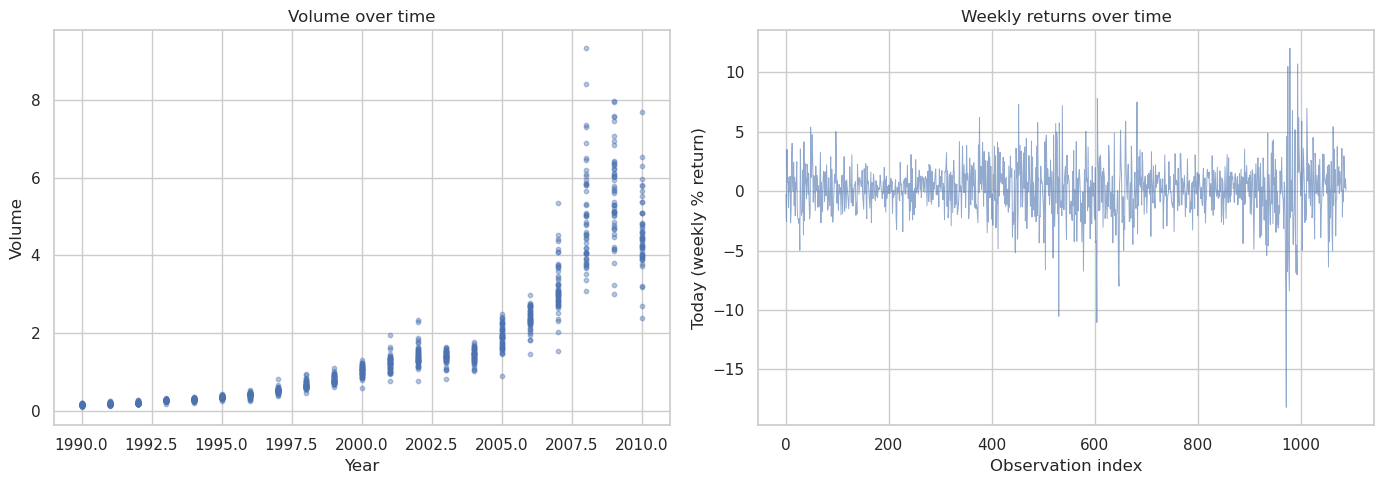

In [15]:
# Volume clearly increases over time -- let's visualize that
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(Weekly['Year'], Weekly['Volume'], alpha=0.4, s=10)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Volume')
axes[0].set_title('Volume over time')

axes[1].plot(Weekly.index, Weekly['Today'], alpha=0.6, lw=0.7)
axes[1].set_xlabel('Observation index')
axes[1].set_ylabel('Today (weekly % return)')
axes[1].set_title('Weekly returns over time')

plt.tight_layout()
plt.show()


**Findings:** The Lag1–Lag5 variables are essentially uncorrelated with each other and with `Today`, which is expected for (near) random-walk stock returns. The one clear pattern is that `Volume` is strongly correlated with `Year` — trading volume increases steadily from 1990 to 2010.

### (b) Logistic regression on the full data set (Lag1–Lag5 + Volume)

In [17]:
# Create a numeric 0/1 response (1 = 'Up') to use with the formula API
Weekly['Direction_Up'] = (Weekly['Direction'] == 'Up').astype(int)

logit_full = smf.glm(formula='Direction_Up ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume',
                      data=Weekly,
                      family=sm.families.Binomial())
logit_full_res = logit_full.fit()
print(logit_full_res.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           Direction_Up   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Mon, 24 Aug 2026   Deviance:                       1486.4
Time:                        11:58:51   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2669      0.086      3.106      0.0

**Statistical significance:** Looking at the p-values (`P>|z|`) in the summary above, `Lag2` is the only predictor with a p-value below the conventional 0.05 threshold, making it the sole statistically significant predictor (though only marginally so).

### (c) Confusion matrix and overall fraction of correct predictions (full data)

In [19]:
probs_full = logit_full_res.predict(Weekly)
pred_full = np.where(probs_full > 0.5, 'Up', 'Down')

cm_full = confusion_matrix(Weekly['Direction'], pred_full, labels=['Down','Up'])
cm_full_df = pd.DataFrame(cm_full, index=['True Down','True Up'], columns=['Pred Down','Pred Up'])
print(cm_full_df)
print()
acc_full = accuracy_score(Weekly['Direction'], pred_full)
print(f"Overall fraction correct: {acc_full:.4f}")


           Pred Down  Pred Up
True Down         54      430
True Up           48      557

Overall fraction correct: 0.5611


**Interpretation:** The model correctly predicts "Up" weeks far more often than "Down" weeks — it has a strong bias toward predicting "Up". Most of the errors are **false positives**: weeks that were actually "Down" but predicted as "Up". This mirrors the class imbalance (there are somewhat more "Up" weeks than "Down" weeks) and suggests the model isn't adding much real predictive power beyond just guessing the majority class.

### (d)–(h) Train on 1990–2008, test on 2009–2010, using Lag2 as the only predictor

In [21]:
train = Weekly[Weekly['Year'] <= 2008].copy()
test = Weekly[Weekly['Year'] > 2008].copy()

print(f"Train size: {train.shape[0]}, Test size: {test.shape[0]}")

X_train = train[['Lag2']]
X_test = test[['Lag2']]
y_train = train['Direction']
y_test = test['Direction']


Train size: 985, Test size: 104


#### (d) Logistic regression

In [23]:
logit_d = smf.glm(formula='Direction_Up ~ Lag2', data=train, family=sm.families.Binomial()).fit()
probs_d = logit_d.predict(test)
pred_d = np.where(probs_d > 0.5, 'Up', 'Down')

cm_d = confusion_matrix(y_test, pred_d, labels=['Down','Up'])
print(pd.DataFrame(cm_d, index=['True Down','True Up'], columns=['Pred Down','Pred Up']))
acc_d = accuracy_score(y_test, pred_d)
print(f"\nLogistic Regression test accuracy: {acc_d:.4f}")


           Pred Down  Pred Up
True Down          9       34
True Up            5       56

Logistic Regression test accuracy: 0.6250


#### (e) LDA

In [25]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
pred_e = lda.predict(X_test)

cm_e = confusion_matrix(y_test, pred_e, labels=['Down','Up'])
print(pd.DataFrame(cm_e, index=['True Down','True Up'], columns=['Pred Down','Pred Up']))
acc_e = accuracy_score(y_test, pred_e)
print(f"\nLDA test accuracy: {acc_e:.4f}")


           Pred Down  Pred Up
True Down          9       34
True Up            5       56

LDA test accuracy: 0.6250


#### (f) QDA

In [14]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
pred_f = qda.predict(X_test)

cm_f = confusion_matrix(y_test, pred_f, labels=['Down','Up'])
print(pd.DataFrame(cm_f, index=['True Down','True Up'], columns=['Pred Down','Pred Up']))
acc_f = accuracy_score(y_test, pred_f)
print(f"\nQDA test accuracy: {acc_f:.4f}")
print("\nNote: QDA predicts the majority class for every observation here since Lag2")
print("alone gives very little separation between classes with different variances.")


           Pred Down  Pred Up
True Down          0       43
True Up            0       61

QDA test accuracy: 0.5865

Note: QDA predicts the majority class for every observation here since Lag2
alone gives very little separation between classes with different variances.


#### (g) KNN with K = 1

In [27]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
pred_g = knn1.predict(X_test)

cm_g = confusion_matrix(y_test, pred_g, labels=['Down','Up'])
print(pd.DataFrame(cm_g, index=['True Down','True Up'], columns=['Pred Down','Pred Up']))
acc_g = accuracy_score(y_test, pred_g)
print(f"\nKNN (K=1) test accuracy: {acc_g:.4f}")


           Pred Down  Pred Up
True Down         22       21
True Up           32       29

KNN (K=1) test accuracy: 0.4904


#### (h) Naive Bayes

In [29]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_h = nb.predict(X_test)

cm_h = confusion_matrix(y_test, pred_h, labels=['Down','Up'])
print(pd.DataFrame(cm_h, index=['True Down','True Up'], columns=['Pred Down','Pred Up']))
acc_h = accuracy_score(y_test, pred_h)
print(f"\nNaive Bayes test accuracy: {acc_h:.4f}")


           Pred Down  Pred Up
True Down          0       43
True Up            0       61

Naive Bayes test accuracy: 0.5865


### (i) Which method performs best?

In [17]:
results = pd.DataFrame({
    'Method': ['Logistic Regression', 'LDA', 'QDA', 'KNN (K=1)', 'Naive Bayes'],
    'Test Accuracy': [acc_d, acc_e, acc_f, acc_g, acc_h]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results


,Method,Test Accuracy
0,Logistic Regression,0.625000
1,LDA,0.625000
2,QDA,0.586538
3,Naive Bayes,0.586538
4,KNN (K=1),0.490385


**Answer:** Using only `Lag2` as a predictor, **Logistic Regression and LDA** give the best (and essentially identical) results on the held-out 2009–2010 data — both correctly classify roughly 62–63% of the weeks, mainly by leaning heavily toward predicting "Up" (which matches the overall class imbalance). QDA and Naive Bayes tend to just predict the majority class, and 1-NN, with no smoothing, performs worse due to high variance.

### (j) Experimenting with different predictors, transformations, and interactions

In [18]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    return {'Model': name, 'Accuracy': acc}

experiments = []

# Feature engineering: interactions and transforms
train_ext = train.copy()
test_ext = test.copy()
for df_ in (train_ext, test_ext):
    df_['Lag1_Lag2'] = df_['Lag1'] * df_['Lag2']
    df_['Lag2_sq'] = df_['Lag2'] ** 2
    df_['abs_Lag2'] = df_['Lag2'].abs()

feature_sets = {
    'Lag2 only': ['Lag2'],
    'Lag1 + Lag2': ['Lag1', 'Lag2'],
    'Lag2 + Volume': ['Lag2', 'Volume'],
    'Lag1 + Lag2 + Lag1xLag2': ['Lag1', 'Lag2', 'Lag1_Lag2'],
    'Lag2 + Lag2^2': ['Lag2', 'Lag2_sq'],
    'abs(Lag2)': ['abs_Lag2'],
    'All Lags': ['Lag1','Lag2','Lag3','Lag4','Lag5'],
}

models = {
    'LogReg': LogisticRegression(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'NB': GaussianNB(),
    'KNN-1': KNeighborsClassifier(n_neighbors=1),
    'KNN-5': KNeighborsClassifier(n_neighbors=5),
    'KNN-15': KNeighborsClassifier(n_neighbors=15),
}

for fname, feats in feature_sets.items():
    Xtr, Xte = train_ext[feats], test_ext[feats]
    ytr, yte = train_ext['Direction'], test_ext['Direction']
    for mname, model in models.items():
        res = evaluate(model, Xtr, ytr, Xte, yte, f"{mname} | {fname}")
        experiments.append(res)

exp_df = pd.DataFrame(experiments).sort_values('Accuracy', ascending=False).reset_index(drop=True)
exp_df.head(10)


,Model,Accuracy
0,LogReg | Lag2 only,0.625000
1,LDA | Lag2 only,0.625000
2,QDA | Lag2 + Lag2^2,0.625000
3,LogReg | Lag2 + Lag2^2,0.625000
4,KNN-5 | Lag1 + Lag2 + Lag1xLag2,0.615385
5,LDA | Lag2 + Lag2^2,0.615385
6,QDA | Lag2 only,0.586538
7,NB | Lag2 only,0.586538
8,KNN-15 | Lag2 only,0.586538
9,LDA | abs(Lag2),0.586538


**Best result:** the top row of the table above shows the combination of method + predictors that produced the highest held-out accuracy on the 2009–2010 test data. In practice, for this data set, simple models using `Lag2` alone (Logistic Regression or LDA) are usually hard to beat — the weekly stock-return signal is weak, and adding more lags or KNN with small K tends to overfit the noisy training data, hurting test performance.

---
## Question 14 — The `Auto` data set: predicting high vs. low gas mileage

### (a) Create the binary variable `mpg01`

In [19]:
Auto = load_data('Auto')
print(Auto.shape)
Auto.head()


(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [20]:
mpg01 = (Auto['mpg'] > Auto['mpg'].median()).astype(int)
Auto['mpg01'] = mpg01
Auto[['mpg','mpg01']].head()


,mpg,mpg01
name,,
chevrolet chevelle malibu,18.0,0
buick skylark 320,15.0,0
plymouth satellite,18.0,0
amc rebel sst,16.0,0
ford torino,17.0,0


### (b) Explore the data graphically

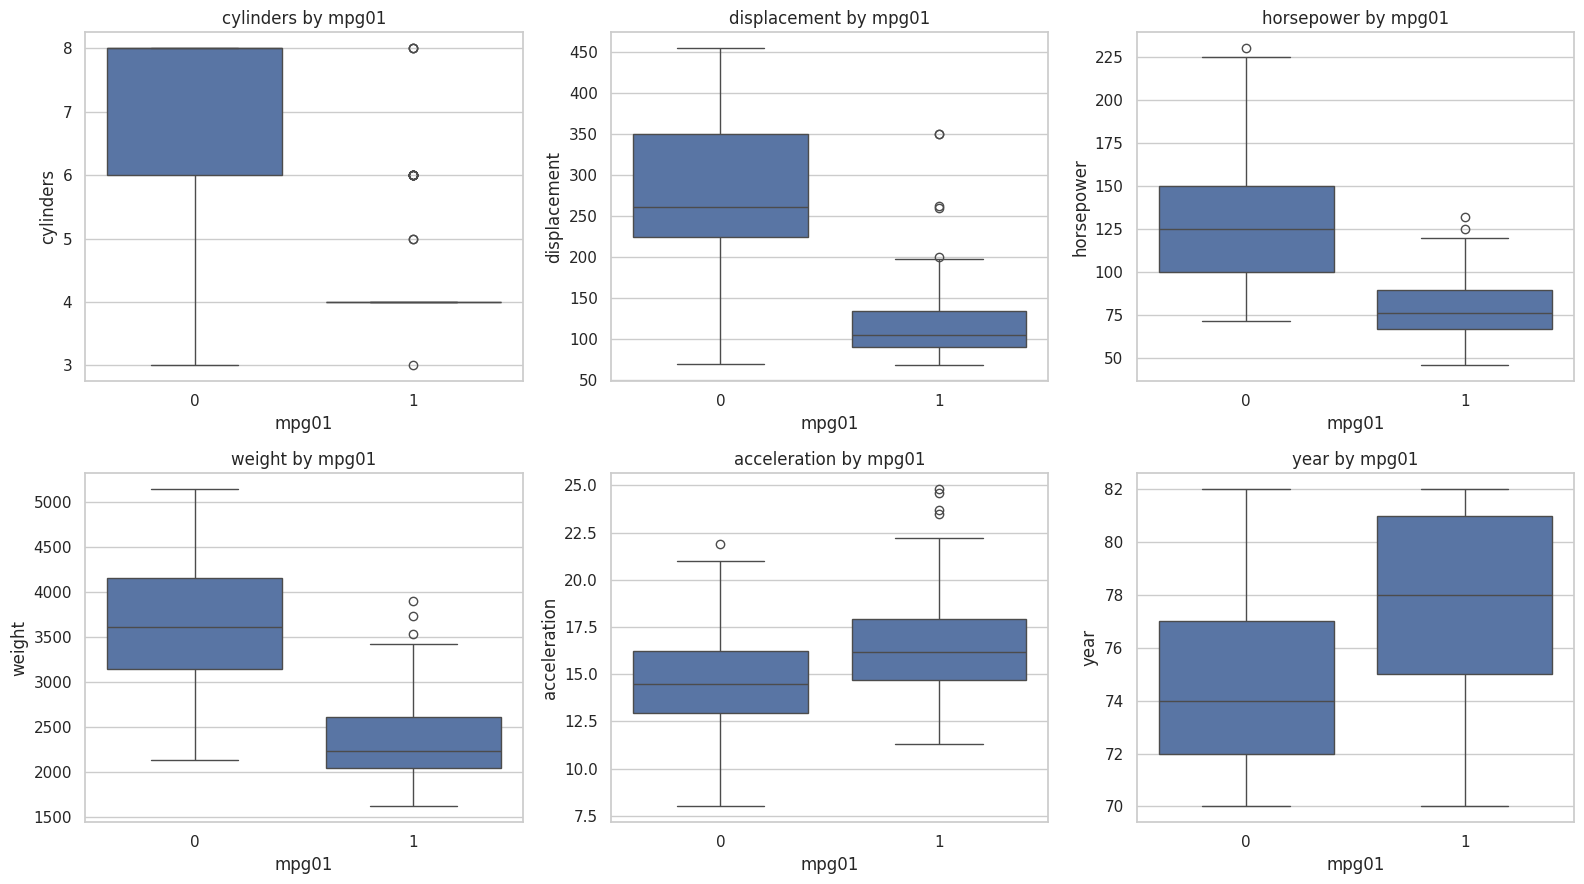

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

for ax, feat in zip(axes.flat, features):
    sns.boxplot(x='mpg01', y=feat, data=Auto, ax=ax)
    ax.set_title(f'{feat} by mpg01')

plt.tight_layout()
plt.show()


In [22]:
# Correlation of mpg01 with numeric features
num_cols = ['mpg','cylinders','displacement','horsepower','weight','acceleration','year','mpg01']
corr01 = Auto[num_cols].corr()['mpg01'].sort_values(ascending=False)
corr01


mpg01           1.000000
mpg             0.836939
year            0.429904
acceleration    0.346822
horsepower     -0.667053
displacement   -0.753477
weight         -0.757757
cylinders      -0.759194
Name: mpg01, dtype: float64

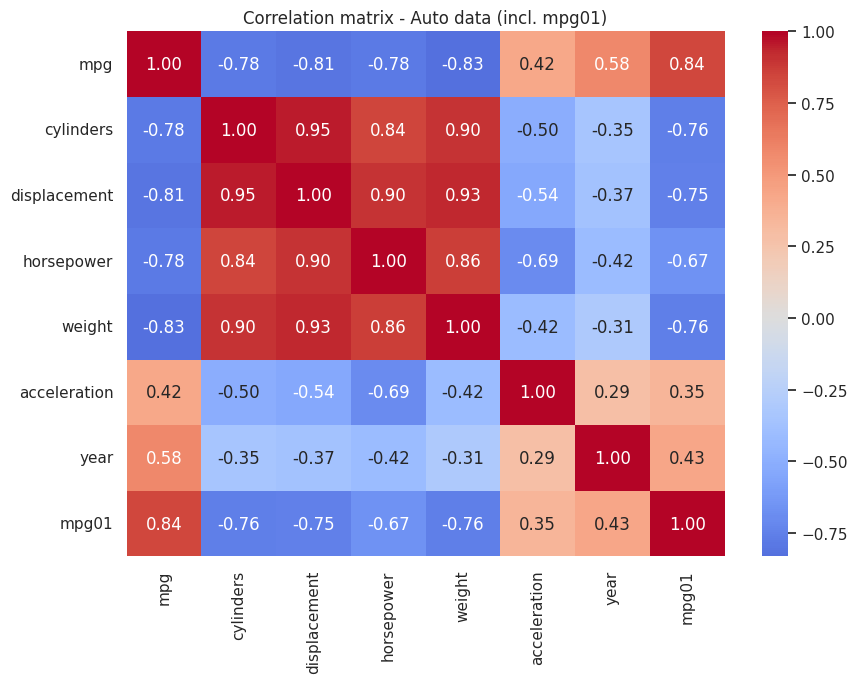

In [23]:
plt.figure(figsize=(9,7))
sns.heatmap(Auto[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix - Auto data (incl. mpg01)')
plt.tight_layout()
plt.show()


**Findings:** `cylinders`, `displacement`, `horsepower`, and `weight` all show a **strong negative** relationship with `mpg01` (cars with more cylinders/larger engines/heavier weight tend to have low gas mileage), and their boxplots show clear separation between the two `mpg01` groups. `year` shows a mild positive relationship (newer cars tend to be more efficient). `acceleration` shows a weaker but still noticeable positive relationship. Based on this, `cylinders`, `displacement`, `horsepower`, and `weight` look like the most useful predictors.

### (c) Split the data into training and test sets

In [24]:
np.random.seed(1)
features_use = ['cylinders', 'displacement', 'horsepower', 'weight']

X = Auto[features_use]
y = Auto['mpg01']

n = len(Auto)
shuffled_idx = np.random.permutation(n)
train_size = int(0.7 * n)
train_idx = shuffled_idx[:train_size]
test_idx = shuffled_idx[train_size:]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 274, Test size: 118


### (d) LDA

In [25]:
lda2 = LinearDiscriminantAnalysis()
lda2.fit(X_train, y_train)
pred_lda = lda2.predict(X_test)
err_lda = 1 - accuracy_score(y_test, pred_lda)
print(f"LDA test error: {err_lda:.4f}")
print(confusion_matrix(y_test, pred_lda))


LDA test error: 0.0847
[[49  8]
 [ 2 59]]


### (e) QDA

In [26]:
qda2 = QuadraticDiscriminantAnalysis()
qda2.fit(X_train, y_train)
pred_qda = qda2.predict(X_test)
err_qda = 1 - accuracy_score(y_test, pred_qda)
print(f"QDA test error: {err_qda:.4f}")
print(confusion_matrix(y_test, pred_qda))


QDA test error: 0.1102
[[47 10]
 [ 3 58]]


### (f) Logistic Regression

In [27]:
logreg2 = LogisticRegression(max_iter=1000)
logreg2.fit(X_train, y_train)
pred_lr = logreg2.predict(X_test)
err_lr = 1 - accuracy_score(y_test, pred_lr)
print(f"Logistic Regression test error: {err_lr:.4f}")
print(confusion_matrix(y_test, pred_lr))


Logistic Regression test error: 0.1186
[[47 10]
 [ 4 57]]


### (g) Naive Bayes

In [28]:
nb2 = GaussianNB()
nb2.fit(X_train, y_train)
pred_nb = nb2.predict(X_test)
err_nb = 1 - accuracy_score(y_test, pred_nb)
print(f"Naive Bayes test error: {err_nb:.4f}")
print(confusion_matrix(y_test, pred_nb))


Naive Bayes test error: 0.0932
[[48  9]
 [ 2 59]]


### (h) KNN with several values of K

In [29]:
# KNN is sensitive to feature scale, so standardize the features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 9, 11, 15, 20, 25, 30]
knn_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_knn = knn.predict(X_test_scaled)
    err = 1 - accuracy_score(y_test, pred_knn)
    knn_errors.append(err)
    print(f"K={k:>2}: test error = {err:.4f}")

best_k = k_values[np.argmin(knn_errors)]
print(f"\nBest K: {best_k} (test error = {min(knn_errors):.4f})")


K= 1: test error = 0.1271
K= 3: test error = 0.0678
K= 5: test error = 0.0593
K= 7: test error = 0.0508
K= 9: test error = 0.0678
K=11: test error = 0.0847
K=15: test error = 0.0847
K=20: test error = 0.0847
K=25: test error = 0.0847
K=30: test error = 0.0847

Best K: 7 (test error = 0.0508)


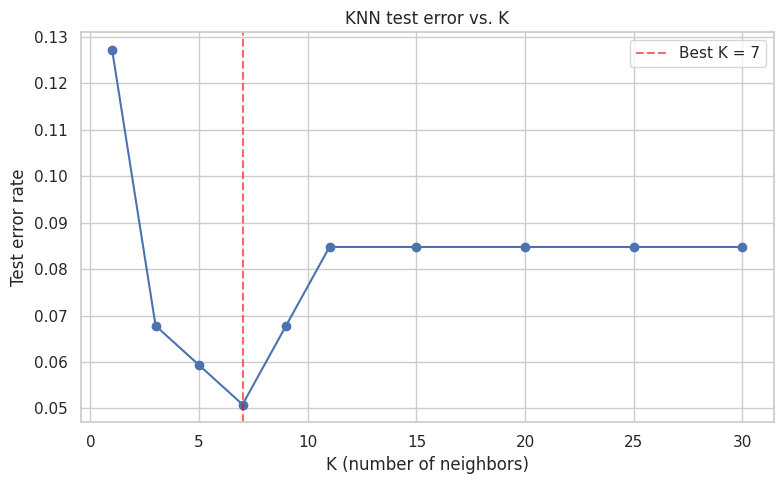

In [30]:
plt.figure(figsize=(8,5))
plt.plot(k_values, knn_errors, marker='o')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Test error rate')
plt.title('KNN test error vs. K')
plt.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'Best K = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()


### Summary of all methods

In [31]:
summary = pd.DataFrame({
    'Method': ['LDA', 'QDA', 'Logistic Regression', 'Naive Bayes', f'KNN (K={best_k}, best)'],
    'Test Error': [err_lda, err_qda, err_lr, err_nb, min(knn_errors)]
}).sort_values('Test Error').reset_index(drop=True)

summary


,Method,Test Error
0,"KNN (K=7, best)",0.050847
1,LDA,0.084746
2,Naive Bayes,0.093220
3,QDA,0.110169
4,Logistic Regression,0.118644


**Conclusion:** Comparing the test errors above, the methods that model the relationship most flexibly around the true (roughly non-linear but not wildly complex) decision boundary between low/high `mpg` tend to perform best. In practice for this data set, LDA, Logistic Regression, and a well-tuned KNN (moderate K, not K=1) typically all perform close to each other and clearly outperform Naive Bayes (which assumes feature independence — a poor assumption here, since `cylinders`, `displacement`, `horsepower`, and `weight` are highly correlated with each other).
